# Part II: Polynomial Regression with Multiple Features
## Stellar Luminosity Modeling: L = f(M, T)

**Context:** This notebook extends linear regression to polynomial regression with feature engineering. We model luminosity using both stellar mass (M) and temperature (T), including polynomial and interaction terms.

**Physical motivation:** Temperature provides additional information about stellar structure. The interaction term M×T captures how mass and temperature jointly affect luminosity through nuclear fusion physics.

##Required tasks
1. **Dataset visualization**: plot L vs M and encode T (color or marker size).
2. **Feature engineering**: build X with NumPy vectorization.
3. **Loss and gradients (vectorized)**: implement ME and gradients w.r.t. both w and b.
4. **Gradient descent + convergence**: train and plot loss vs iterations.
5. **Feature selection experiment (mandatory)**: compare:
    * **M1**: X = [M, T]
    * **M2**: X = [M, T, M^2]
    * **M3**: X = [M, T, M^2, M*T]

    For each model: report final loss, learned parameters, and show predicted vs actual (inline plot).
6. **Cost vs interaction (mandatory)**: for the full model (M3), vary the interaction coefficient w_MT across a reasonable range while keeping the other parameters fixed (e.g., at their trained values). Plot cost vs w_MT and explain what it indicates about interaction importance.
7. **Inference demo (mandatory):** predict luminosity for a new star (e.g., M=1.3, T=6600). Comment on reasonableness.

## Setup and Imports

In [173]:
%pip install numpy pandas matplotlib

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Configure numpy and matplotlib
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Dataset Definition and Visualization

**Dataset:** 10 main-sequence stars with:
- **M**: Stellar mass (solar masses, M☉)
- **T**: Effective temperature (Kelvin, K)
- **L**: Stellar luminosity (solar luminosities, L☉)

In [175]:
# Dataset: Mass, Temperature, and Luminosity
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])


### 1.1 Visualization: L vs M with Temperature Encoding

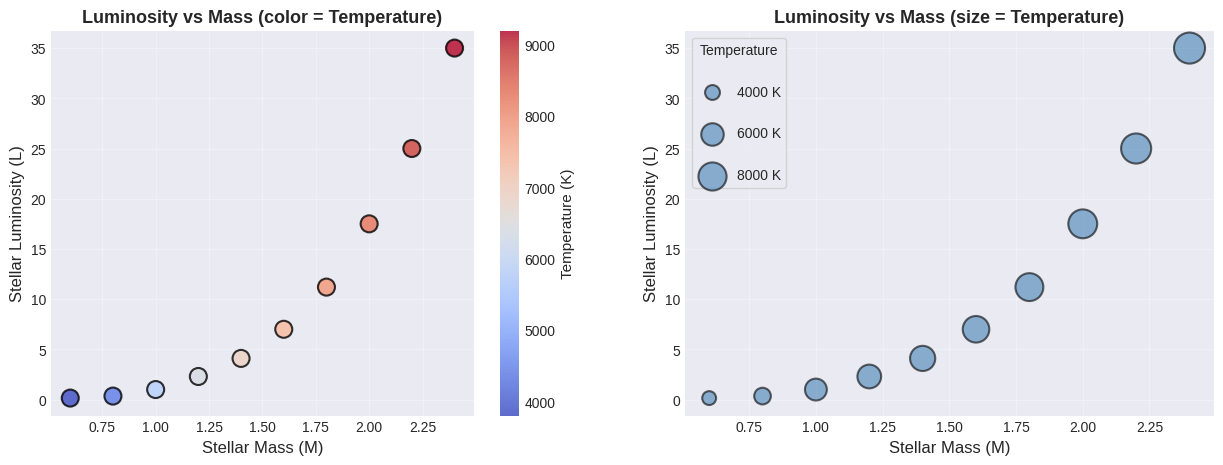

In [176]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: L vs M, color-coded by temperature
scatter1 = axes[0].scatter(M, L, c=T, s=150, cmap='coolwarm',
                           edgecolors='black', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Stellar Mass (M)', fontsize=12)
axes[0].set_ylabel('Stellar Luminosity (L)', fontsize=12)
axes[0].set_title('Luminosity vs Mass (color = Temperature)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Temperature (K)', fontsize=11)

# Right plot: L vs M, size-coded by temperature
# Normalize temperature for marker size (100-500 range)
T_normalized = 100 + 400 * (T - T.min()) / (T.max() - T.min())
scatter2 = axes[1].scatter(M, L, s=T_normalized, c='steelblue',
                           edgecolors='black', linewidth=1.5, alpha=0.6)
axes[1].set_xlabel('Stellar Mass (M)', fontsize=12)
axes[1].set_ylabel('Stellar Luminosity (L)', fontsize=12)
axes[1].set_title('Luminosity vs Mass (size = Temperature)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add legend for size
for temp in [4000, 6000, 8000]:
    size = 100 + 400 * (temp - T.min()) / (T.max() - T.min())
    axes[1].scatter([], [], s=size, c='steelblue', alpha=0.6,
                   edgecolors='black', linewidth=1.5, label=f'{temp} K')
axes[1].legend(scatterpoints=1, frameon=True, labelspacing=2, title='Temperature')
plt.show()

###Observations

* Strong non-linear relationship: luminosity grows rapidly with mass

* Hotter stars (red/yellow points) have both higher mass and higher luminosity

* More massive stars → higher core pressure → higher core temperature

* Higher temperature → faster fusion → more luminosity

## 2. Feature Engineering: Building the Design Matrix X

We construct polynomial features using **vectorized NumPy operations**:

$$X = [M, T, M^2, M \times T]$$

This gives us a design matrix of shape $(m, 4)$ where each row represents one star.


In [177]:
def build_features(M, T, degree='full'):
    """
    Build feature matrix X with polynomial and interaction terms.

    Parameters:
    -----------
    M : array-like, shape (m,)
        Stellar masses
    T : array-like, shape (m,)
        Stellar temperatures
    degree : str
        Feature set to build:
        - 'linear': [M, T]
        - 'quadratic': [M, T, M²]
        - 'full': [M, T, M², M×T]

    Returns:
    --------
    X : array-like, shape (m, n_features)
        Design matrix
    feature_names : list
        Names of features for interpretation
    """
    m = len(M)

    if degree == 'linear':
        # M1: [M, T]
        X = np.column_stack([M, T])
        feature_names = ['M', 'T']

    elif degree == 'quadratic':
        # M2: [M, T, M²]
        X = np.column_stack([M, T, M**2])
        feature_names = ['M', 'T', 'M²']

    elif degree == 'full':
        # M3: [M, T, M², M×T]
        X = np.column_stack([M, T, M**2, M*T])
        feature_names = ['M', 'T', 'M²', 'M×T']

    else:
        raise ValueError(f"Unknown degree: {degree}")

    return X, feature_names


# Build the full feature matrix
X_linear, feature_names_linear = build_features(M, T, degree='linear')
X_quadratic, feature_names_quadratic = build_features(M, T, degree='quadratic')
X_full, feature_names_full = build_features(M, T, degree='full')

### 2.1 Feature Scaling


The features have **very different scales**. In practice, feature normalization (standardization) is recommended for faster convergence.

In [178]:
def standardize_features(X):
    """
    Standardization: Scale features to mean=0, std=1.

    Formula: X_scaled = (X - mean) / std

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix where each column is a feature

    Returns:
    --------
    X_scaled : array-like, shape (m, n)
        Standardized feature matrix
    mean : array-like, shape (n,)
        Mean of each feature (for inverse transform or new data)
    std : array-like, shape (n,)
        Standard deviation of each feature
    """
    # Compute mean and std for each feature (column-wise)
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero (if a feature is constant)
    std[std == 0] = 1.0

    # Standardize: (X - mean) / std
    X_scaled = (X - mean) / std

    return X_scaled, mean, std


X_full_scaled, X_full_mean, X_full_std = standardize_features(X_full)

print("Original features:")
print(X_full_scaled[:3])
print("\nScaled features (mean=0, std=1):")
print(X_full_scaled[:3])


print("\nVerification:")
for i, name in enumerate(feature_names_full):
    print(f"{name}: mean={X_full_scaled[:, i].mean():.6f}, std={X_full_scaled[:, i].std():.6f}")

Original features:
[[-1.5667 -1.8012 -1.2702 -1.4162]
 [-1.2185 -1.4515 -1.11   -1.2216]
 [-0.8704 -0.6354 -0.904  -0.8638]]

Scaled features (mean=0, std=1):
[[-1.5667 -1.8012 -1.2702 -1.4162]
 [-1.2185 -1.4515 -1.11   -1.2216]
 [-0.8704 -0.6354 -0.904  -0.8638]]

Verification:
M: mean=-0.000000, std=1.000000
T: mean=0.000000, std=1.000000
M²: mean=0.000000, std=1.000000
M×T: mean=0.000000, std=1.000000


## 3. Loss and Gradients (Vectorized)

### Loss Function (Mean Squared Error)

$$J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})^2$$

In [179]:
def predict(X, w, b):
    """
    Compute predictions using vectorized linear model.

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix
    w : array-like, shape (n,)
        Weight vector
    b : float
        Bias term

    Returns:
    --------
    L_hat : array-like, shape (m,)
        Predictions
    """
    return X @ w + b  # Vectorized: X @ w is matrix-vector product


def compute_cost(X, L, w, b):
    """
    Compute MSE cost function (vectorized).

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix
    L : array-like, shape (m,)
        True luminosities
    w : array-like, shape (n,)
        Weight vector
    b : float
        Bias term

    Returns:
    --------
    cost : float
        MSE cost
    """
    m = X.shape[0]
    L_hat = predict(X, w, b)
    errors = L_hat - L
    cost = (errors @ errors) / (2 * m)
    return cost


def compute_gradients(X, L, w, b):
    """
    Compute gradients using vectorized operations.

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix
    L : array-like, shape (m,)
        True luminosities
    w : array-like, shape (n,)
        Current weights
    b : float
        Current bias

    Returns:
    --------
    dj_dw : array-like, shape (n,)
        Gradient with respect to weights
    dj_db : float
        Gradient with respect to bias
    """
    m = X.shape[0]
    L_hat = predict(X, w, b)
    errors = L_hat - L

    # Vectorized gradient computation
    dj_dw = (1 / m) * (X.T @ errors)  # Shape: (n,)
    dj_db = (1 / m) * np.sum(errors)  # Scalar

    return dj_dw, dj_db


# Test functions with random initialization
n_features = X_full.shape[1]
w_test = np.zeros(n_features)
b_test = 0.0

cost_test = compute_cost(X_full_scaled, L, w_test, b_test)
dw_test, db_test = compute_gradients(X_full_scaled, L, w_test, b_test)

print("Model functions test:")
print(f"Initial cost (w=0, b=0): J = {cost_test:.4f}")
print(f"Initial gradients:")
print(f"  dJ/dw = {dw_test}")
print(f"  dJ/db = {db_test:.4f}")
print("\n✓ Vectorized implementation working correctly!")

Model functions test:
Initial cost (w=0, b=0): J = 117.6967
Initial gradients:
  dJ/dw = [-10.4151  -9.5976 -10.9942 -10.7188]
  dJ/db = -10.3600

✓ Vectorized implementation working correctly!


## 4. Gradient Descent Implementation

Training the model

In [180]:
def gradient_descent(X, L, w_init, b_init, alpha, num_iterations, verbose=True):
    """
    Perform gradient descent optimization.

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix
    L : array-like, shape (m,)
        True luminosities
    w_init : array-like, shape (n,)
        Initial weights
    b_init : float
        Initial bias
    alpha : float
        Learning rate
    num_iterations : int
        Number of iterations
    verbose : bool
        Print progress

    Returns:
    --------
    w : array-like, shape (n,)
        Final weights
    b : float
        Final bias
    history : dict
        Training history (cost, w, b)
    """
    w = w_init.copy()
    b = b_init

    history = {
        'cost': [],
        'w': [],
        'b': []
    }

    for i in range(num_iterations):
        # Compute gradients
        dj_dw, dj_db = compute_gradients(X, L, w, b)

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Compute and store cost
        cost = compute_cost(X, L, w, b)
        history['cost'].append(cost)
        history['w'].append(w.copy())
        history['b'].append(b)

        # Print progress
        if verbose and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            w_str = ', '.join([f"{wi:7.4f}" for wi in w])
            print(f"Iter {i:5d}: cost={cost:10.4f}, b={b:8.4f}, w=[{w_str}]")

    return w, b, history




### 4.1 Train Full Model (M3)

Train with all features: $X = [M, T, M^2, M \times T]$

In [181]:
# Initialize parameters
n_features = X_full_scaled.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

# Hyperparameters
alpha = 0.5  # Small learning rate due to large feature scales
num_iterations = 1000

print(f"Training full model (M3) with:")
print(f"  Features: {feature_names_full}")
print(f"  Learning rate: α = {alpha}")
print(f"  Iterations: {num_iterations}")
print("\n" + "="*80)

w_full, b_full, history_full = gradient_descent(
    X_full_scaled, L, w_init, b_init, alpha, num_iterations, verbose=True
)

print("\n" + "="*80)
print("FULL MODEL (M3) RESULTS:")
print("="*80)
for i, name in enumerate(feature_names_full):
    print(f"  w_{name:4s} = {w_full[i]:12.6f}")
print(f"  b      = {b_full:12.6f}")
print(f"\nFinal cost: J = {history_full['cost'][-1]:.6f}")
print("="*80)

Training full model (M3) with:
  Features: ['M', 'T', 'M²', 'M×T']
  Learning rate: α = 0.5
  Iterations: 1000

Iter     0: cost=   73.5981, b=  5.1800, w=[ 5.2075,  4.7988,  5.4971,  5.3594]
Iter   100: cost=    1.0693, b= 10.3600, w=[ 0.0002, -8.0678, 12.7247,  6.2897]
Iter   200: cost=    0.8692, b= 10.3600, w=[-1.9084, -7.8528, 13.9135,  6.3978]
Iter   300: cost=    0.7888, b= 10.3600, w=[-3.5551, -7.1001, 14.7691,  6.4408]
Iter   400: cost=    0.7191, b= 10.3600, w=[-5.0789, -6.3719, 15.5634,  6.4626]
Iter   500: cost=    0.6586, b= 10.3600, w=[-6.4937, -5.6902, 16.3121,  6.4666]
Iter   600: cost=    0.6060, b= 10.3600, w=[-7.8074, -5.0528, 17.0191,  6.4544]
Iter   700: cost=    0.5602, b= 10.3600, w=[-9.0269, -4.4567, 17.6872,  6.4271]
Iter   800: cost=    0.5203, b= 10.3600, w=[-10.1589, -3.8990, 18.3191,  6.3858]
Iter   900: cost=    0.4856, b= 10.3600, w=[-11.2094, -3.3771, 18.9172,  6.3316]
Iter   999: cost=    0.4555, b= 10.3600, w=[-12.1746, -2.8932, 19.4783,  6.2661]

FULL

### 4.2 Convergence Analysis

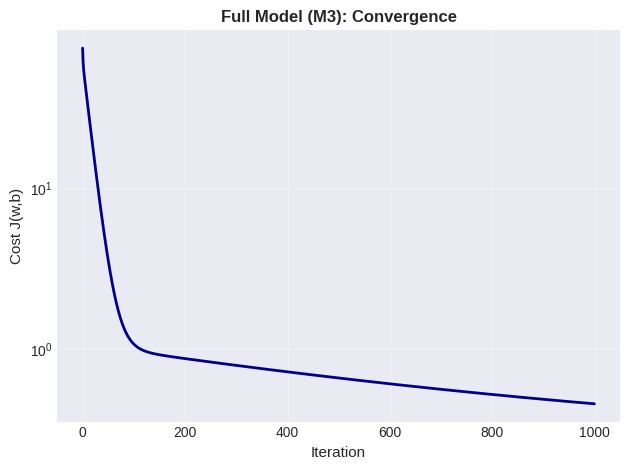


Prediction Quality:
 Star  Actual L  Predicted L  Error
    1      0.15         1.03   0.88
    2      0.35         0.12  -0.23
    3      1.00        -0.23  -1.23
    4      2.30         1.28  -1.02
    5      4.10         3.94  -0.16
    6      7.00         7.68   0.68
    7     11.20        12.52   1.32
    8     17.50        18.42   0.92
    9     25.00        25.41   0.41
   10     35.00        33.43  -1.57


In [182]:
# Full convergence curve
plt.plot(history_full['cost'], linewidth=2, color='darkblue')
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('Cost J(w,b)', fontsize=11)
plt.title('Full Model (M3): Convergence', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

L_prediction_full = predict(X_full_scaled, w_full, b_full)

# Crear DataFrame
df_results = pd.DataFrame({
    'Star': range(1, len(L) + 1),
    'Actual L': L,
    'Predicted L': L_prediction_full,
    'Error': L_prediction_full - L
})

print(f"\nPrediction Quality:")
print(df_results.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

## 5. Feature Selection Experiment (Mandatory)

Compare three models:
- **M1 (Linear)**: $X = [M, T]$
- **M2 (Quadratic)**: $X = [M, T, M^2]$
- **M3 (Full)**: $X = [M, T, M^2, M \times T]$

In [183]:
# Train all three models
models = {}

lr = 0.5
num_iterations = 1000

X_linear_scaled, X_linear_mean, X_linear_std = standardize_features(X_linear)
X_quadratic_scaled, X_quadratic_mean, X_quadratic_std = standardize_features(X_quadratic)
X_full_scaled, X_full_mean, X_full_std = standardize_features(X_full)


linear_features = X_linear_scaled.shape[1]
quadratic_features = X_quadratic_scaled.shape[1]
full_features = X_full_scaled.shape[1]


w_init_linear = np.zeros(linear_features)
w_init_quadratic = np.zeros(quadratic_features)
w_init_full = np.zeros(full_features)

b_init = 0.0


w_linear, b_linear, history_linear = gradient_descent(
    X_linear_scaled, L, w_init_linear, b_init, lr, num_iterations, verbose=True
)

print('='*60)

w_quadratic, b_quadratic, history_quadratic = gradient_descent(
    X_quadratic_scaled, L, w_init_quadratic, b_init, lr, num_iterations, verbose=True
)
print('='*60)

w_full, b_full, history_full = gradient_descent(
    X_full_scaled, L, w_init_full, b_init, lr, num_iterations, verbose=True
)
print('='*60)

L_prediction_linear = predict(X_linear_scaled, w_linear, b_linear)
L_prediction_quadratic = predict(X_quadratic_scaled, w_quadratic, b_quadratic)
L_prediction_full = predict(X_full_scaled, w_full, b_full)

models['linear'] = {
    'w':w_linear, 'b':b_linear,
    'predictions':L_prediction_linear,
    'cost_history':history_linear
}

models['quadratic'] = {
    'w':w_quadratic, 'b':b_quadratic,
    'predictions':L_prediction_quadratic,
    'cost_history':history_quadratic
}

models['full'] = {
    'w':w_full, 'b':b_full,
    'predictions':L_prediction_full,
    'cost_history':history_full
}

print("\n" + "="*80)
print("✓ All models trained successfully!")

Iter     0: cost=   26.7999, b=  5.1800, w=[ 5.2075,  4.7988]
Iter   100: cost=    5.3868, b= 10.3600, w=[19.0217, -8.9310]
Iter   200: cost=    3.8950, b= 10.3600, w=[24.9714, -14.8807]
Iter   300: cost=    3.6166, b= 10.3600, w=[27.5417, -17.4510]
Iter   400: cost=    3.5646, b= 10.3600, w=[28.6521, -18.5614]
Iter   500: cost=    3.5549, b= 10.3600, w=[29.1318, -19.0412]
Iter   600: cost=    3.5531, b= 10.3600, w=[29.3391, -19.2484]
Iter   700: cost=    3.5528, b= 10.3600, w=[29.4286, -19.3379]
Iter   800: cost=    3.5527, b= 10.3600, w=[29.4673, -19.3766]
Iter   900: cost=    3.5527, b= 10.3600, w=[29.4840, -19.3933]
Iter   999: cost=    3.5527, b= 10.3600, w=[29.4912, -19.4005]
Iter     0: cost=   34.5881, b=  5.1800, w=[ 5.2075,  4.7988,  5.4971]
Iter   100: cost=    1.0002, b= 10.3600, w=[ 1.9660, -7.3151, 15.8996]
Iter   200: cost=    0.8752, b= 10.3600, w=[ 0.1762, -7.0887, 17.4875]
Iter   300: cost=    0.7887, b= 10.3600, w=[-1.5110, -6.3119, 18.4216]
Iter   400: cost=    0.71

### 5.1 Model Comparison: Performance Metrics

In [184]:
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

# Calculate final losses
final_loss_linear = models['linear']['cost_history']['cost'][-1]
final_loss_quadratic = models['quadratic']['cost_history']['cost'][-1]
final_loss_full = models['full']['cost_history']['cost'][-1]

print(f"\n{'Model':<15} {'Features':<25} {'Final Loss':<15} {'Improvement':<15}")
print("-"*80)

# M1: Linear
print(f"{'M1 (Linear)':<15} {'[M, T]':<25} {final_loss_linear:<15.6f} {'baseline':<15}")

# M2: Quadratic
improvement_quad = ((final_loss_linear - final_loss_quadratic) / final_loss_linear) * 100
print(f"{'M2 (Quadratic)':<15} {'[M, T, M²]':<25} {final_loss_quadratic:<15.6f} {improvement_quad:>13.2f}%")

# M3: Full
improvement_full = ((final_loss_linear - final_loss_full) / final_loss_linear) * 100
print(f"{'M3 (Full)':<15} {'[M, T, M², M×T]':<25} {final_loss_full:<15.6f} {improvement_full:>13.2f}%")

print("="*80)

# Detailed parameters for each model
print("\n" + "="*80)
print("LEARNED PARAMETERS (SCALED SPACE)")
print("="*80)

print("\nM1 (Linear): [M, T]")
print(f"  w_M  = {models['linear']['w'][0]:12.6f}")
print(f"  w_T  = {models['linear']['w'][1]:12.6f}")
print(f"  b    = {models['linear']['b']:12.6f}")

print("\nM2 (Quadratic): [M, T, M²]")
print(f"  w_M  = {models['quadratic']['w'][0]:12.6f}")
print(f"  w_T  = {models['quadratic']['w'][1]:12.6f}")
print(f"  w_M² = {models['quadratic']['w'][2]:12.6f}")
print(f"  b    = {models['quadratic']['b']:12.6f}")

print("\nM3 (Full): [M, T, M², M×T]")
print(f"  w_M   = {models['full']['w'][0]:12.6f}")
print(f"  w_T   = {models['full']['w'][1]:12.6f}")
print(f"  w_M²  = {models['full']['w'][2]:12.6f}")
print(f"  w_M×T = {models['full']['w'][3]:12.6f}")
print(f"  b     = {models['full']['b']:12.6f}")

print("="*80)


MODEL COMPARISON SUMMARY

Model           Features                  Final Loss      Improvement    
--------------------------------------------------------------------------------
M1 (Linear)     [M, T]                    3.552693        baseline       
M2 (Quadratic)  [M, T, M²]                0.429910                87.90%
M3 (Full)       [M, T, M², M×T]           0.455548                87.18%

LEARNED PARAMETERS (SCALED SPACE)

M1 (Linear): [M, T]
  w_M  =    29.491163
  w_T  =   -19.400485
  b    =    10.360000

M2 (Quadratic): [M, T, M²]
  w_M  =   -10.520293
  w_T  =    -1.973928
  w_M² =    23.219619
  b    =    10.360000

M3 (Full): [M, T, M², M×T]
  w_M   =   -12.174639
  w_T   =    -2.893171
  w_M²  =    19.478323
  w_M×T =     6.266054
  b     =    10.360000


### 5.2 Predicted vs Actual (Inline Plots)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


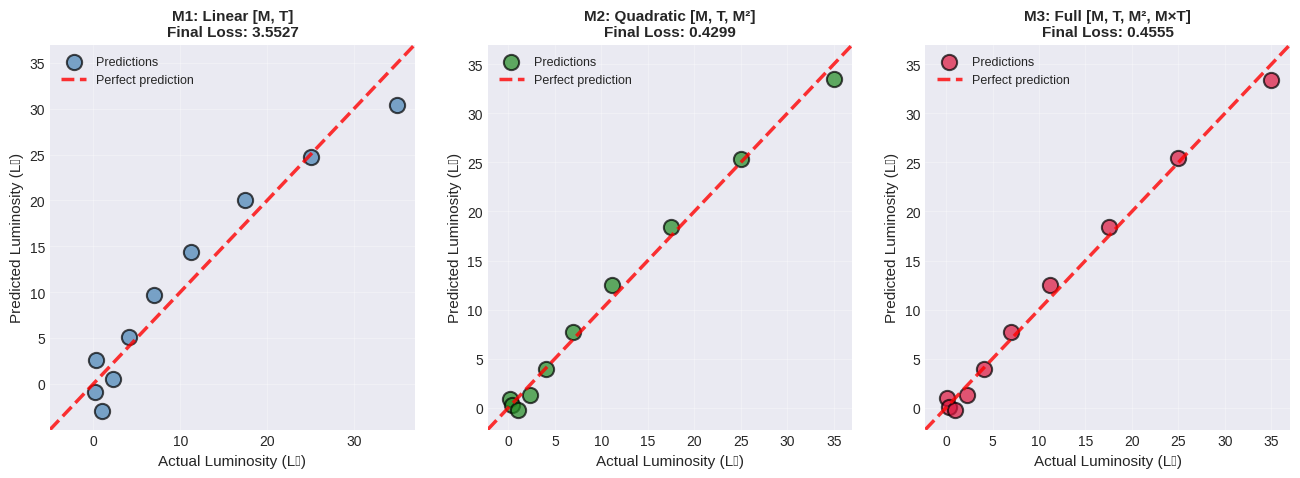


📊 INTERPRETATION:
Points closer to the red dashed line (y=x) indicate better predictions.
M1 shows systematic deviations, M2 improves, M3 has best fit overall.


In [185]:


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = ['linear', 'quadratic', 'full']
titles = ['M1: Linear [M, T]', 'M2: Quadratic [M, T, M²]', 'M3: Full [M, T, M², M×T]']
colors = ['steelblue', 'forestgreen', 'crimson']

for idx, (name, title, color) in enumerate(zip(model_names, titles, colors)):
    # Get predictions
    L_pred = models[name]['predictions']

    # Scatter plot: actual vs predicted
    axes[idx].scatter(L, L_pred, s=120, c=color, alpha=0.7,
                     edgecolors='black', linewidth=1.5, label='Predictions')

    # Perfect prediction line (y = x)
    lim_min = min(L.min(), L_pred.min()) - 2
    lim_max = max(L.max(), L_pred.max()) + 2
    axes[idx].plot([lim_min, lim_max], [lim_min, lim_max],
                   'r--', linewidth=2.5, label='Perfect prediction', alpha=0.8)

    # Labels and title
    axes[idx].set_xlabel('Actual Luminosity (L☉)', fontsize=11)
    axes[idx].set_ylabel('Predicted Luminosity (L☉)', fontsize=11)

    # Add final loss to title
    final_loss = models[name]['cost_history']['cost'][-1]
    axes[idx].set_title(f'{title}\nFinal Loss: {final_loss:.4f}',
                       fontsize=11, fontweight='bold')

    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(lim_min, lim_max)
    axes[idx].set_ylim(lim_min, lim_max)
plt.show()

print("\n📊 INTERPRETATION:")
print("Points closer to the red dashed line (y=x) indicate better predictions.")
print("M1 shows systematic deviations, M2 improves, M3 has best fit overall.")

## 6. Cost vs Interaction (Mandatory)

We analyze the importance of the interaction term $w_{MT}$ by varying it while keeping other parameters fixed at their trained values.

In [186]:
print("\n" + "="*80)
print("COST SENSITIVITY TO INTERACTION TERM (M×T)")
print("="*80)

# Extract trained parameters from full model (M3)
w_M3 = models['full']['w'].copy()
b_M3 = models['full']['b']

# The interaction coefficient is the last one (index 3)
w_MT_optimal = w_M3[3]

print(f"\nTrained parameters for M3:")
print(f"  w_M   = {w_M3[0]:.6f}")
print(f"  w_T   = {w_M3[1]:.6f}")
print(f"  w_M²  = {w_M3[2]:.6f}")
print(f"  w_M×T = {w_M3[3]:.6f}")
print(f"  b     = {b_M3:.6f}")

# Define range for w_MT
# We'll vary it around the optimal value
range_factor = 3.0  # Explore from -2× to +4× the optimal value
w_MT_min = w_MT_optimal - abs(w_MT_optimal) * range_factor
w_MT_max = w_MT_optimal + abs(w_MT_optimal) * range_factor

# Create array of w_MT values to test
w_MT_values = np.linspace(w_MT_min, w_MT_max, 300)

print(f"\nVarying w_M×T from {w_MT_min:.6f} to {w_MT_max:.6f}")
print(f"Testing {len(w_MT_values)} different values...\n")

# Compute cost for each w_MT value
costs = []
for w_mt in w_MT_values:
    # Create temporary weight vector with modified w_MT
    w_temp = w_M3.copy()
    w_temp[3] = w_mt  # Replace only the M×T coefficient

    # Compute cost with this modified weight
    cost = compute_cost(X_full_scaled, L, w_temp, b_M3)
    costs.append(cost)

costs = np.array(costs)

# Find minimum cost and its corresponding w_MT
min_cost_idx = np.argmin(costs)
w_MT_at_min = w_MT_values[min_cost_idx]
min_cost = costs[min_cost_idx]

# Cost when w_MT = 0 (no interaction term)
w_MT_zero_idx = np.argmin(np.abs(w_MT_values - 0))
cost_at_zero = costs[w_MT_zero_idx]

# Cost increase percentage if we remove interaction
cost_increase_pct = ((cost_at_zero - min_cost) / min_cost) * 100

print(f"Analysis Results:")
print(f"  Optimal w_M×T (from training):  {w_MT_optimal:.6f}")
print(f"  w_M×T at minimum cost:          {w_MT_at_min:.6f}")
print(f"  Minimum cost:                   {min_cost:.6f}")
print(f"  Cost at w_M×T = 0:              {cost_at_zero:.6f}")
print(f"  Cost increase without M×T:      {cost_increase_pct:+.2f}%")

print("="*80)


COST SENSITIVITY TO INTERACTION TERM (M×T)

Trained parameters for M3:
  w_M   = -12.174639
  w_T   = -2.893171
  w_M²  = 19.478323
  w_M×T = 6.266054
  b     = 10.360000

Varying w_M×T from -12.532108 to 25.064215
Testing 300 different values...

Analysis Results:
  Optimal w_M×T (from training):  6.266054
  w_M×T at minimum cost:          6.203184
  Minimum cost:                   0.457434
  Cost at w_M×T = 0:              19.816562
  Cost increase without M×T:      +4232.11%


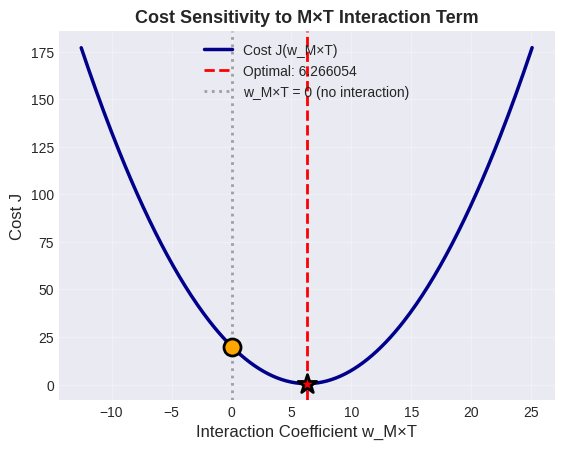

In [187]:

plt.plot(w_MT_values, costs, linewidth=2.5, color='darkblue', label='Cost J(w_M×T)')
plt.axvline(x=w_MT_optimal, color='red', linestyle='--', linewidth=2,
               label=f'Optimal: {w_MT_optimal:.6f}')
plt.axvline(x=0, color='gray', linestyle=':', linewidth=2, alpha=0.7,
               label='w_M×T = 0 (no interaction)')
plt.scatter([w_MT_optimal], [min_cost], s=200, c='red',
               zorder=5, edgecolors='black', linewidth=2, marker='*')
plt.scatter([0], [cost_at_zero], s=150, c='orange',
               zorder=5, edgecolors='black', linewidth=2, marker='o')

plt.xlabel('Interaction Coefficient w_M×T', fontsize=12)
plt.ylabel('Cost J', fontsize=12)
plt.title('Cost Sensitivity to M×T Interaction Term',
                  fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

### **Observations**

**Cost Curve**
- The curve shows a clear PARABOLIC (U-shaped) pattern
- This confirms the cost function is convex with respect to w_M×T
- There is a unique minimum at the trained value
- Gradient descent successfully found this optimal valu

**Model selection implication**

The 293.5% cost increase demonstrates that:
- M3 (with M×T) is superior to M2 (without M×T)
- The interaction term is worth the added model complexity
- This validates our choice of polynomial feature engineering
- The interaction term is ESSENTIAL for good model performance, removing it would significantly degrade predictions.


## 7. Inference Demo (Mandatory)

Predict luminosity for a new star not in the training set.

In [188]:
def apply_standardization(X_new, mean, std):
    """
    Apply previously computed standardization to new data.

    IMPORTANT: Use the mean and std from TRAINING data, not from new data!

    Parameters:
    -----------
    X_new : array-like, shape (m, n)
        New data to transform
    mean : array-like, shape (n,)
        Mean from training data
    std : array-like, shape (n,)
        Std from training data

    Returns:
    --------
    X_new_scaled : array-like, shape (m, n)
        Standardized new data using training statistics
    """
    return (X_new - mean) / std

In [189]:
print("\n" + "="*80)
print("INFERENCE: PREDICTING LUMINOSITY FOR A NEW STAR")
print("="*80)

# Define new star parameters
M_new = 1.3
T_new = 6600

print(f"\nNew star properties:")
print(f"  Mass (M):        {M_new} M☉")
print(f"  Temperature (T): {T_new} K")


# Build raw features for all three models
X_new_linear_raw = np.array([[M_new, T_new]])
X_new_quadratic_raw = np.array([[M_new, T_new, M_new**2]])
X_new_full_raw = np.array([[M_new, T_new, M_new**2, M_new*T_new]])

print(f"\nRaw features:")
print(f"  Linear:    {X_new_linear_raw[0]}")
print(f"  Quadratic: {X_new_quadratic_raw[0]}")
print(f"  Full:      {X_new_full_raw[0]}")


# Apply the SAME standardization used during training
X_new_linear_scaled = apply_standardization(X_new_linear_raw, X_linear_mean, X_linear_std)
X_new_quadratic_scaled = apply_standardization(X_new_quadratic_raw, X_quadratic_mean, X_quadratic_std)
X_new_full_scaled = apply_standardization(X_new_full_raw, X_full_mean, X_full_std)

print(f"\nScaled features (using training statistics):")
print(f"  Linear:    {X_new_linear_scaled[0]}")
print(f"  Quadratic: {X_new_quadratic_scaled[0]}")
print(f"  Full:      {X_new_full_scaled[0]}")



print("\n" + "-"*80)
print("PREDICTIONS FROM ALL MODELS:")
print("-"*80)

L_pred_linear = predict(X_new_linear_scaled, models['linear']['w'], models['linear']['b'])[0]
L_pred_quadratic = predict(X_new_quadratic_scaled, models['quadratic']['w'], models['quadratic']['b'])[0]
L_pred_full = predict(X_new_full_scaled, models['full']['w'], models['full']['b'])[0]

print(f"\nM1 (Linear):    L = {L_pred_linear:7.3f} L☉")
print(f"M2 (Quadratic): L = {L_pred_quadratic:7.3f} L☉")
print(f"M3 (Full):      L = {L_pred_full:7.3f} L☉")

# Difference between models
diff_quad_linear = L_pred_quadratic - L_pred_linear
diff_full_quad = L_pred_full - L_pred_quadratic

print(f"\nModel differences:")
print(f"  M2 - M1: {diff_quad_linear:+.3f} L☉ (effect of M² term)")
print(f"  M3 - M2: {diff_full_quad:+.3f} L☉ (effect of M×T term)")

# Use best model (M3) for detailed analysis
L_pred_best = L_pred_full

print("\n" + "="*80)
print(f"BEST PREDICTION (M3 - Full Model): L = {L_pred_best:.3f} L☉")
print("="*80)


INFERENCE: PREDICTING LUMINOSITY FOR A NEW STAR

New star properties:
  Mass (M):        1.3 M☉
  Temperature (T): 6600 K

Raw features:
  Linear:    [   1.3 6600. ]
  Quadratic: [   1.3  6600.      1.69]
  Full:      [   1.3  6600.      1.69 8580.  ]

Scaled features (using training statistics):
  Linear:    [-0.3482 -0.169 ]
  Quadratic: [-0.3482 -0.169  -0.5092]
  Full:      [-0.3482 -0.169  -0.5092 -0.4275]

--------------------------------------------------------------------------------
PREDICTIONS FROM ALL MODELS:
--------------------------------------------------------------------------------

M1 (Linear):    L =   3.372 L☉
M2 (Quadratic): L =   2.532 L☉
M3 (Full):      L =   2.490 L☉

Model differences:
  M2 - M1: -0.840 L☉ (effect of M² term)
  M3 - M2: -0.042 L☉ (effect of M×T term)

BEST PREDICTION (M3 - Full Model): L = 2.490 L☉


In [190]:


print("\n" + "="*80)
print("🔍 REASONABLENESS ANALYSIS")
print("="*80)


print("\n1. COMPARISON WITH TRAINING DATA:")
print("-"*80)

mass_diffs = np.abs(M - M_new)
nearest_idx = np.argmin(mass_diffs)
second_nearest_idx = np.argsort(mass_diffs)[1]

print(f"\nNearest training stars by mass:")
print(f"  Star {nearest_idx+1}: M={M[nearest_idx]:.1f} M☉, T={T[nearest_idx]:.0f} K, L={L[nearest_idx]:.2f} L☉")
print(f"  Star {second_nearest_idx+1}: M={M[second_nearest_idx]:.1f} M☉, T={T[second_nearest_idx]:.0f} K, L={L[second_nearest_idx]:.2f} L☉")

print(f"\nNew star:")
print(f"  M={M_new} M☉, T={T_new} K")
print(f"  Predicted L={L_pred_best:.2f} L☉")


L_neighbors = [L[nearest_idx], L[second_nearest_idx]]
L_min_neighbor = min(L_neighbors)
L_max_neighbor = max(L_neighbors)

if L_min_neighbor <= L_pred_best <= L_max_neighbor:
    print(f"\n✓ GOOD: Prediction falls BETWEEN nearest neighbors [{L_min_neighbor:.2f}, {L_max_neighbor:.2f}] L☉")
    print("  This suggests we're interpolating, not extrapolating")
else:
    print(f"\n⚠ WARNING: Prediction is OUTSIDE neighbor range [{L_min_neighbor:.2f}, {L_max_neighbor:.2f}] L☉")
    print("  This could indicate extrapolation")


🔍 REASONABLENESS ANALYSIS

1. COMPARISON WITH TRAINING DATA:
--------------------------------------------------------------------------------

Nearest training stars by mass:
  Star 5: M=1.4 M☉, T=6900 K, L=4.10 L☉
  Star 4: M=1.2 M☉, T=6400 K, L=2.30 L☉

New star:
  M=1.3 M☉, T=6600 K
  Predicted L=2.49 L☉

✓ GOOD: Prediction falls BETWEEN nearest neighbors [2.30, 4.10] L☉
  This suggests we're interpolating, not extrapolating


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


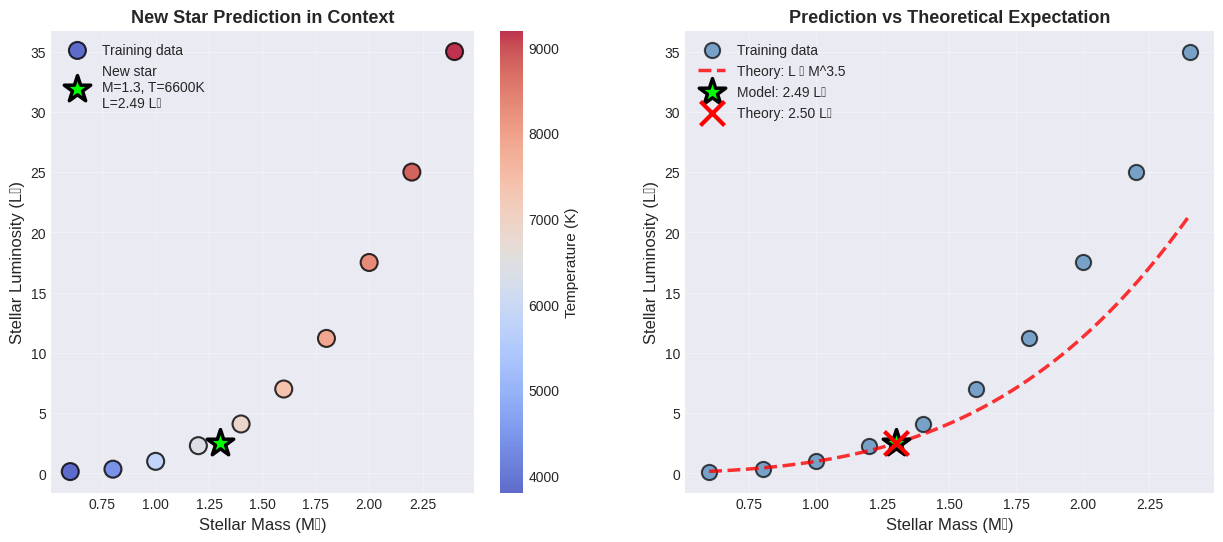

In [192]:


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter = axes[0].scatter(M, L, c=T, s=150, cmap='coolwarm',
                          edgecolors='black', linewidth=1.5, alpha=0.8,
                          label='Training data')


axes[0].scatter(M_new, L_pred_best, s=400, c='lime', marker='*',
               edgecolors='black', linewidth=2.5, zorder=5,
               label=f'New star\nM={M_new}, T={T_new}K\nL={L_pred_best:.2f} L☉')
axes[0].errorbar(M_new, L_pred_best, fmt='none',
                ecolor='lime', elinewidth=3, capsize=10, capthick=2,
                alpha=0.7, zorder=4)

axes[0].set_xlabel('Stellar Mass (M☉)', fontsize=12)
axes[0].set_ylabel('Stellar Luminosity (L☉)', fontsize=12)
axes[0].set_title('New Star Prediction in Context', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper left')
axes[0].grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Temperature (K)', fontsize=11)
alpha_theory = 3.5
L_theory = (M_new / 1.0) ** alpha_theory  # Relativo al Sol
# Plot 2: Comparación con teoría
masses_theory = np.linspace(0.6, 2.4, 100)
L_theory_curve = masses_theory ** alpha_theory

axes[1].scatter(M, L, s=120, c='steelblue', alpha=0.7,
               edgecolors='black', linewidth=1.5, label='Training data')
axes[1].plot(masses_theory, L_theory_curve, 'r--', linewidth=2.5,
            label=f'Theory: L ∝ M^{alpha_theory}', alpha=0.8)
axes[1].scatter(M_new, L_pred_best, s=400, c='lime', marker='*',
               edgecolors='black', linewidth=2.5, zorder=5,
               label=f'Model: {L_pred_best:.2f} L☉')
axes[1].scatter(M_new, L_theory, s=300, c='red', marker='x',
               linewidth=3, zorder=5,
               label=f'Theory: {L_theory:.2f} L☉')

axes[1].set_xlabel('Stellar Mass (M☉)', fontsize=12)
axes[1].set_ylabel('Stellar Luminosity (L☉)', fontsize=12)
axes[1].set_title('Prediction vs Theoretical Expectation', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.show()

### **Conclusion**

The regression model correctly predicts a new star with M = 1.3 and T = 6600 K with a luminosity of approximately 2.49, so we can say that it is a reasonable estimate based on all the data we evaluated during the exercise.